In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_6554/2102599123.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/tmp/ipykernel_6554/2102599123.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


90.5
-33.5


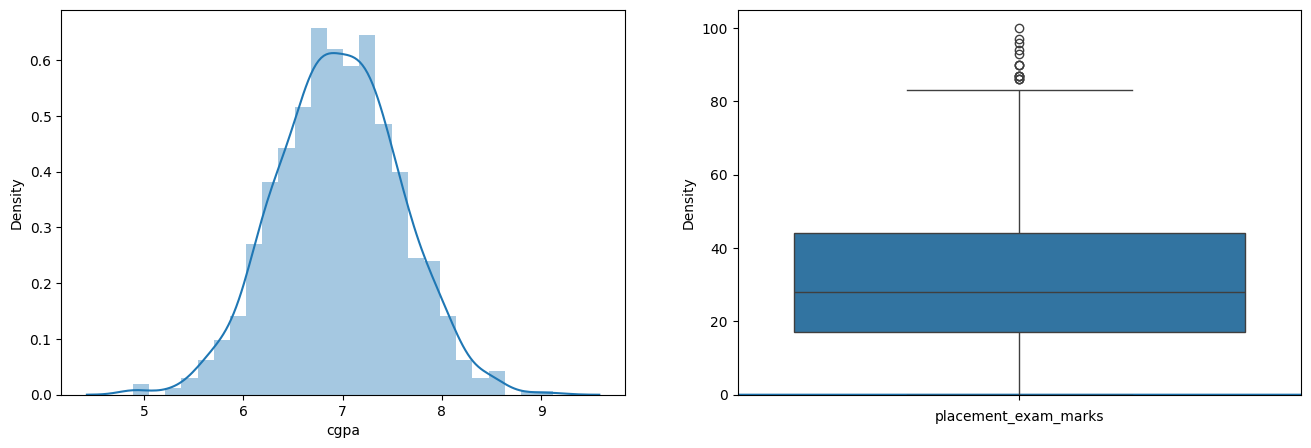

In [9]:
######## this method is used for skewed ########
df = pd.read_csv('/content/placement (1).csv')
df
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
### box plot
sns.boxplot(df['placement_exam_marks'])
###
# here exam placed is right skwed so we apply (IQR method)
df['placement_exam_marks'].describe()
#find iqr
percentile_15=df['placement_exam_marks'].quantile(0.15)
percentile_75=df['placement_exam_marks'].quantile(0.75)
iqr=percentile_75-percentile_15
upper_limit=percentile_75+1.5*iqr
lower_limit=percentile_15-1.5*iqr
print(upper_limit)
print(lower_limit)

### for trimming
new_df = df[df['placement_exam_marks'] < upper_limit]

## for capping
new_df_cap=df.copy()
new_df_cap['cgpa']=np.where(new_df_cap['placement_exam_marks']>upper_limit,upper_limit,
                            np.where(new_df_cap['placement_exam_marks']<lower_limit,lower_limit,
                                    new_df_cap['placement_exam_marks'] )
                            )

